# 02 — Why DQN self-play doesn't reach Nash (exactly, on Leduc)

Plain DQN self-play violates the stationarity Q-learning needs: the opponent moves while you learn. This notebook makes that **exact** on Leduc Hold'em using the committed exploitability metric (`src/leduc_eval.py`), reproduced from `results/exploitability.json`.

*Exploitability (NashConv)* = how much a best response beats the strategy; **0 = exact Nash**.

In [1]:
import os, sys, json
# Walk up to the repo root (works whether the kernel cwd is notebooks/ or root).
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, "results"))
          and os.path.isdir(os.path.join(ROOT, "src"))) \
        and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from IPython.display import Image, display

def load(name):
    with open(os.path.join(ROOT, "results", name)) as f:
        return json.load(f)

def fig(name):
    display(Image(filename=os.path.join(ROOT, "figures", name)))
print("repo root:", ROOT)

repo root: /Users/bozte/Desktop/poker-simulation


## The two regimes: time-average vs last-iterate

CFR's **time-average** strategy converges toward Nash (exploitability → 0). The greedy **last-iterate** — the regime a DQN self-play agent actually plays in — stays exploitable and does *not* converge.

In [2]:
e = load("exploitability.json")
curve = e["curve"]
a0, aN = curve[0]["avg_exploitability"], curve[-1]["avg_exploitability"]
lN = curve[-1]["last_iterate_exploitability"]
print(f"iterations: {curve[0]['iters']} -> {curve[-1]['iters']}")
print(f"time-AVERAGE exploitability: {a0:.3f} -> {aN:.4f}   (-> Nash)")
print(f"greedy LAST-ITERATE        : {lN:.3f}              (stays exploitable)")
if e.get("uniform_exploitability") is not None:
    print(f"uniform-random baseline    : {e['uniform_exploitability']:.3f}")

iterations: 10 -> 10000
time-AVERAGE exploitability: 0.433 -> 0.0014   (-> Nash)
greedy LAST-ITERATE        : 0.355              (stays exploitable)
uniform-random baseline    : 4.033


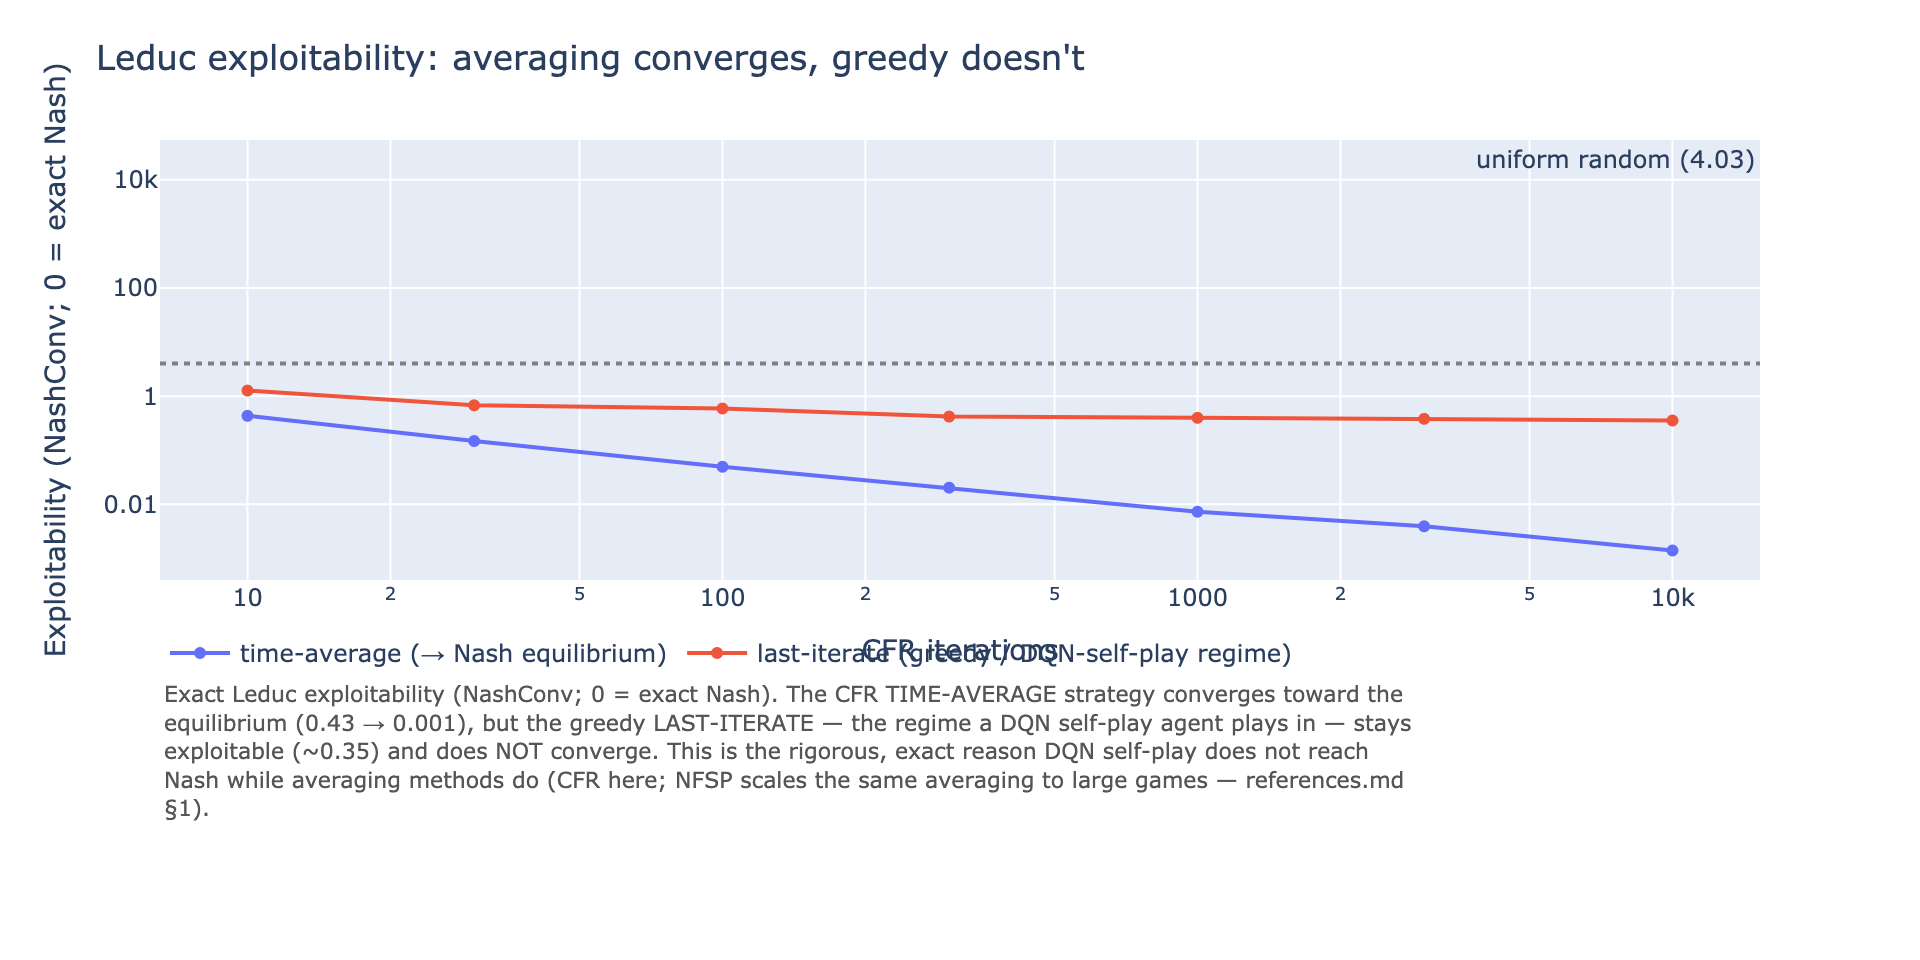

In [3]:
fig("exploitability.png")

## Live check: the metric, recomputed on a known strategy

To show the metric itself is real (not a stored number), compute the exploitability of the uniform-random strategy directly — it should match the committed `uniform_exploitability` above.

In [4]:
from src.leduc_eval import exploitability_of, uniform_strategy_table
live = exploitability_of(uniform_strategy_table())
print(f"live uniform exploitability = {live:.4f}")
print(f"committed                   = {e.get('uniform_exploitability')}")

live uniform exploitability = 4.0333
committed                   = 4.033333333333335


### Takeaway

Averaging methods reach Nash; greedy last-iterate self-play does not. This is the precise, verifiable reason DQN self-play here is a *deliberate baseline*, not a Nash solver. The theoretically grounded next step is **NFSP** (Heinrich & Silver 2016), which carries this averaging to large games via a neural average-policy network (`references.md` §1).